# 01 — Likelihood Analysis of a bright point source with fermipy

This notebook follows the outline of <https://github.com/fermiPy/fermipy-extra/blob/master/notebooks/pg1553.ipynb> for the analysis of PG 1553+113. The original sample analysis is based on the LAT-team study of PG 1553+113 in [Abdo et al. 2010, ApJ 708, 1310](https://ui.adsabs.harvard.edu/abs/2010ApJ...708.1310A) and closely follows the FSSC [Likelihood Analysis with Python](https://fermi.gsfc.nasa.gov/ssc/data/analysis/scitools/python_tutorial.html) thread. fermipy docs: <https://fermipy.readthedocs.io>.

## Get the Data

For this thread the original data were extracted from the [LAT data server](https://fermi.gsfc.nasa.gov/cgi-bin/ssc/LAT/LATDataQuery.cgi) with the following selections (close to the parameters in Abdo+2010):

* Search Center (RA, Dec) = (238.929, 11.1901)
* Radius = 20°  
* Start Time (MET) = 239 557 417 s   (2008-08-04 15:43:37 UTC)
* Stop Time  (MET) = 256 970 880 s   (2009-02-22 04:48:00 UTC)
* Minimum Energy = 100 MeV
* Maximum Energy = 300 GeV

Our local FT1 / FT2 are already in `data/pg1553/` (you saw them in notebook 00). 

In [1]:
import os
from pathlib import Path

# Working directory
ANADIR = Path("/Users/mcrnogor/Library/CloudStorage/Dropbox/"
              "lectures/fermipy/lecture/data/pg1553")

os.environ['FERMI_DIFFUSE_DIR'] = (
    "/Users/mcrnogor/miniconda3/envs/fermipy/share/"
    "fermitools/refdata/fermi/galdiffuse"
)

os.chdir(ANADIR)
print("working in:", os.getcwd())
print("\ncontents:")
for p in sorted(ANADIR.iterdir()):
    print(f"  {p.name}")

working in: /Users/mcrnogor/Library/CloudStorage/Dropbox/lectures/fermipy/lecture/data/pg1553

contents:
  4fgl_j1555.7+1111_sed.fits
  4fgl_j1555.7+1111_sed.npy
  L2605041209056812327D95_PH00.fits
  L2605041209056812327D95_PH01.fits
  L2605041209056812327D95_PH02.fits
  L2605041209056812327D95_SC00.fits
  PG1553_filtered.fits
  PG1553_mktime.fits
  bexpmap_00.fits
  bexpmap_roi_00.fits
  ccube.fits
  ccube_00.fits
  config.yaml
  events.txt
  evfile_00.txt
  fermipy (Milena Crnogorčević's conflicted copy 2026-05-04).log
  fermipy.log
  fit0.fits
  fit0.npy
  fit0_00.xml
  fit0_counts_map_2.000_5.477.png
  fit0_counts_map_xproj_2.000_5.477.png
  fit0_counts_map_yproj_2.000_5.477.png
  fit0_counts_spectrum.png
  fit0_model_map_2.000_5.477.png
  ft1.txt
  ft1_00.fits
  ft2.txt
  gtbin.par
  gtexpcube2.par
  gtltcube.par
  gtselect.par
  gtsrcmaps.par
  ltcube_00.fits
  mcube_fit0.fits
  mcube_fit0_00.fits
  scfile_00.txt
  srcmap_00.fits
  srcmdl_00.xml


### Make a file list

fermipy needs a text file listing the FT1 chunks (and a similar one for FT2). We already wrote `ft1.txt` and `ft2.txt` into the working directory.

In [2]:
print("=== ft1.txt ===")
print(open("ft1.txt").read())
print("=== ft2.txt ===")
print(open("ft2.txt").read())

=== ft1.txt ===
L2605041209056812327D95_PH00.fits
L2605041209056812327D95_PH01.fits
L2605041209056812327D95_PH02.fits

=== ft2.txt ===
L2605041209056812327D95_SC00.fits



## Make a config file

fermipy's analysis is configured through a [yaml](https://yaml.org) file. Knowing what to put in the config file is half the job.

* `data.evfile` / `data.scfile`: the FT1 / FT2 listfiles.
* `binning`: 10° ROI side, 0.1°/pixel, 8 bins/decade in energy.
* `selection`: 100 MeV–300 GeV, MET window matches the LAT-server query, `evclass=128` (SOURCE), `evtype=3` (FRONT+BACK), `target='4FGL J1555.7+1111'`.
* `gtlike`: enable energy dispersion (`edisp=True`) with the `P8R3_SOURCE_V3` IRFs.
* `model`: 15° model-source ROI (slightly *larger* than the 10° fit ROI so PSF tails leak in correctly), galactic + isotropic diffuse from `$FERMI_DIFFUSE_DIR`, 4FGL catalog (fermipy 1.4.0 ships up to DR4 — the alias `'4FGL'` resolves to the latest available).

Full config reference: <https://fermipy.readthedocs.io/en/latest/config.html>.

In [3]:
print(open("config.yaml").read())

data:
  evfile : ft1.txt
  scfile : ft2.txt
  ltcube  : ltcube_00.fits

binning:
  roiwidth   : 10.0
  binsz      : 0.1
  binsperdec : 8

selection :
  emin : 100
  emax : 300000
  tmin: 239557417
  tmax: 256970880
  zmax    : 90
  evclass : 128
  evtype  : 3
  target : '4FGL J1555.7+1111'

gtlike:
  edisp : True
  irfs : 'P8R3_SOURCE_V3'

model:
  src_roiwidth : 15.0
  galdiff  : '$FERMI_DIFFUSE_DIR/gll_iem_v07.fits'
  isodiff  : '$FERMI_DIFFUSE_DIR/iso_P8R3_SOURCE_V3_v1.txt'
  catalogs :
    - '4FGL'



## Start the analysis

We start `GTAnalysis(config.yaml)`, then run `gta.setup()` which executes the rest of the FSSC analysis chain (`gtselect` → `gtmktime` → `gtltcube` → `gtbin` → `gtexpcube2` → `gtsrcmaps`) and stages every intermediate product under the working directory.

This is where the "magic" happens: fermipy loads the catalog, builds an XML source model for everything in the ROI, picks all the cuts and binnings, and runs the science tools for us. If files already exist, it skips the corresponding step — so the *first* `gta.setup()` is slow (~15–30 min on a laptop for our time interval, dominated by `gtltcube` and `gtsrcmaps`); subsequent calls are seconds.

### Load up some modules

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

Silence a couple of harmless deprecation warnings emitted by the underlying tools.

In [5]:
import warnings
try:
    from matplotlib import MatplotlibDeprecationWarning
    warnings.filterwarnings("ignore", category=MatplotlibDeprecationWarning)
except ImportError:
    pass
warnings.filterwarnings("ignore", category=FutureWarning)

### Import the GTAnalysis module from fermipy

Constructing the object reads the config and prints every parameter fermipy is going to use — including the many defaults you didn't override. Verbosity 3 = INFO (suppresses DEBUG).

In [6]:
from fermipy.gtanalysis import GTAnalysis
gta = GTAnalysis("config.yaml", logging={"verbosity": 3})
matplotlib.interactive(True)

2026-05-04 22:39:16 INFO    GTAnalysis.__init__(): 
--------------------------------------------------------------------------------
fermipy version 1.4.0 
ScienceTools version 2.2.0


Let's take a look at the initial input event files,

In [7]:
with open("ft1.txt") as f:
    input_files = [line.strip() for line in f if line.strip()]
print(input_files)

['L2605041209056812327D95_PH00.fits', 'L2605041209056812327D95_PH01.fits', 'L2605041209056812327D95_PH02.fits']


...and read one of them as an `astropy.table.Table`...

In [8]:
from astropy.table import Table
t = Table.read(input_files[0], hdu=1)
t

ENERGY,RA,DEC,L,B,THETA,PHI,ZENITH_ANGLE,EARTH_AZIMUTH_ANGLE,TIME,EVENT_ID,RUN_ID,RECON_VERSION,CALIB_VERSION,EVENT_CLASS,EVENT_TYPE,CONVERSION_TYPE,LIVETIME,DIFRSP0,DIFRSP1,DIFRSP2,DIFRSP3,DIFRSP4
MeV,deg,deg,deg,deg,deg,deg,deg,deg,s,,,,,,,,s,,,,,
float32,float32,float32,float32,float32,float32,float32,float32,float32,float64,int32,int32,int16,int16[3],bool[32],bool[32],int16,float64,float32,float32,float32,float32,float32
538.79675,258.76797,11.601158,32.717495,26.587275,21.099522,69.525536,39.699387,302.11157,239646594.1632708,3154345,239645594,0,0 .. 0,False .. True,False .. True,0,130.803790807724,0.0,0.0,0.0,0.0,0.0
765.5338,258.56604,11.574936,32.59832,26.756044,57.46366,200.40448,70.16773,66.16222,239840161.56974736,8362449,239835659,0,0 .. 0,False .. True,False .. True,0,76.85447326302528,0.0,0.0,0.0,0.0,0.0
391.90915,258.77057,11.551644,32.668377,26.564293,66.689735,252.94148,38.697117,33.092915,239898124.18749014,2213352,239897571,0,0 .. 0,False .. True,False .. False,1,56.99404388666153,0.0,0.0,0.0,0.0,0.0
120.571365,258.83325,11.796055,32.94541,26.610472,44.83362,96.635826,54.28294,276.6544,239951043.89974436,1003061,239950625,0,0 .. 0,False .. True,False .. False,1,123.81579771637917,0.0,0.0,0.0,0.0,0.0
500.81796,258.63654,11.483924,32.538124,26.655235,48.03507,98.21642,57.537155,275.82956,239951099.17692286,1148299,239950625,0,0 .. 0,False .. True,False .. True,0,179.09297621250153,0.0,0.0,0.0,0.0,0.0
56.917747,259.25488,11.808055,33.149467,26.240242,27.207922,93.00075,35.593727,286.64346,239973638.5377804,182859,239973542,0,0 .. 0,False .. True,False .. False,1,93.56106162071228,0.0,0.0,0.0,0.0,0.0
393.2541,259.0739,11.939454,33.20065,26.455925,32.59749,194.16124,39.280994,38.334652,240030010.17818636,10147729,240025172,0,0 .. 0,False .. True,False .. True,0,24.26987051963806,0.0,0.0,0.0,0.0,0.0
260.86182,258.9468,12.058491,33.264046,26.618439,61.366016,281.5017,31.956478,287.96527,240036675.37049332,336220,240036563,0,0 .. 0,False .. True,False .. True,0,109.3906192779541,0.0,0.0,0.0,0.0,0.0


### The setup routine

`gta.setup()` runs every preprocessing step needed before likelihood. fermipy will *skip* any ancillary file that already exists — so re-running this cell after an interrupt is safe.

**First-run cost.** On our 6.5-month window expect ~15–30 min; the bottlenecks are `gtltcube` (livetime cube, all-sky × cos θ × time) and `gtsrcmaps` (one model map per source in the ROI, convolved with PSF and exposure). Re-runs that find the cached `*_00.fits` files complete in seconds.

In [9]:
gta.setup(overwrite=True)

2026-05-04 22:39:22 INFO    GTAnalysis.setup(): Running setup.
2026-05-04 22:39:23 INFO    GTBinnedAnalysis.setup(): Running setup for component 00
2026-05-04 22:39:23 INFO    GTBinnedAnalysis.run_gtapp(): Running gtselect.
2026-05-04 22:39:23 INFO    GTBinnedAnalysis.run_gtapp(): time -p gtselect infile=/Users/mcrnogor/Library/CloudStorage/Dropbox/lectures/fermipy/lecture/data/pg1553/evfile_00.txt outfile=/Users/mcrnogor/Library/CloudStorage/Dropbox/lectures/fermipy/lecture/data/pg1553/ft1_00.fits ra=238.93130493164062 dec=11.188400268554688 rad=7.5710678118654755 tmin=239557417.0 tmax=256970880.0 emin=100.0 emax=300000.0 zmin=0.0 zmax=90.0 evclass=128 evtype=3 convtype=-1 phasemin=0.0 phasemax=1.0 evtable="EVENTS" chatter=3 clobber=yes debug=no gui=no mode="ql"
2026-05-04 22:39:23 INFO    GTBinnedAnalysis.run_gtapp(): This is gtselect version HEAD
2026-05-04 22:39:23 INFO    GTBinnedAnalysis.run_gtapp(): Applying filter string: ((EVENT_CLASS&o200) != o0) && angsep(RA,DEC,238.9313049,

Before proceeding we have a quick look at what fermipy produced.

In [10]:
import glob
for f in sorted(glob.glob("*.fits")):
    print(f)

4fgl_j1555.7+1111_sed.fits
L2605041209056812327D95_PH00.fits
L2605041209056812327D95_PH01.fits
L2605041209056812327D95_PH02.fits
L2605041209056812327D95_SC00.fits
PG1553_filtered.fits
PG1553_mktime.fits
bexpmap_00.fits
bexpmap_roi_00.fits
ccube.fits
ccube_00.fits
fit0.fits
ft1_00.fits
ltcube_00.fits
mcube_fit0.fits
mcube_fit0_00.fits
srcmap_00.fits


Brief explanation of the contents of each file and its role in the analysis:

* **`ft1_00.fits`** — Event list. Generated by running `gtselect` and `gtmktime` on our input file list.
* **`bexpmap_00.fits`** — All-sky binned exposure map. Interpolated to create the exposure model when generating the source-map file.
* **`bexpmap_roi_00.fits`** — Binned exposure map *for the ROI*. Provided for visualisation (same binning as data and model maps).
* **`ccube_00.fits`** — Counts cube for the ROI (energy × lon × lat).
* **`ltcube_00.fits`** — Livetime cube. Map of the livetime over the whole sky as a function of incidence angle.
* **`srcmap_00.fits`** — Source-map cube. One map per ROI component, after convolution with exposure and PSF. (Energy dispersion is applied at run-time.)

The `_00` suffix is the analysis-component index — a multi-component analysis would have `_00`, `_01`, …, plus co-added maps without an index for visualisation.

To see one of these, open the counts cube and sum it over energy to make a 2-D sky image.

Filename: ccube.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      28   (100, 100, 28)   float32   
  1  EBOUNDS       1 BinTableHDU     22   28R x 4C   [K, D, D, D]   


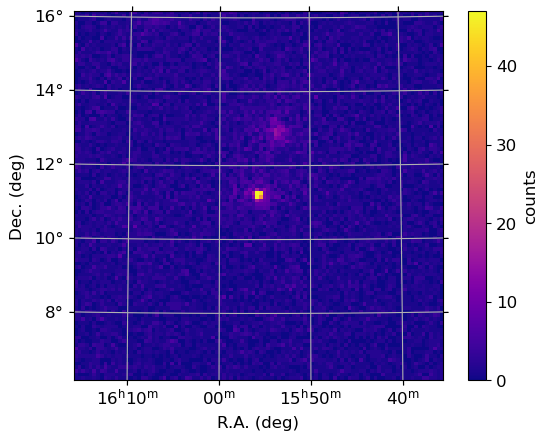

In [11]:
from astropy.io import fits
from astropy.wcs import WCS

h = fits.open('ccube.fits')
h.info()

wcs = WCS(h[0].header).dropaxis(-1)   # drop the energy axis for plotting

counts = h[0].data
plt.subplot(projection=wcs)
im = plt.imshow(np.sum(counts, axis=0), interpolation='nearest',
                origin='lower', cmap='plasma')
plt.colorbar(im, label="counts")
plt.grid()
plt.gca().tick_params(direction='out')
plt.gca().set_xlabel("R.A. (deg)")
plt.gca().set_ylabel("Dec. (deg)")

Next, the sky map of the exposure for the ROI:

Filename: bexpmap_roi_00.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      56   (100, 100, 29)   float32   
  1  ENERGIES      1 BinTableHDU     13   29R x 1C   [1D]   
  2  GTI           1 BinTableHDU     18   3066R x 2C   [D, D]   


the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
Set MJD-OBS to 54682.655283 from DATE-OBS.
Set MJD-END to 54884.199977 from DATE-END'. [astropy.wcs.wcs]


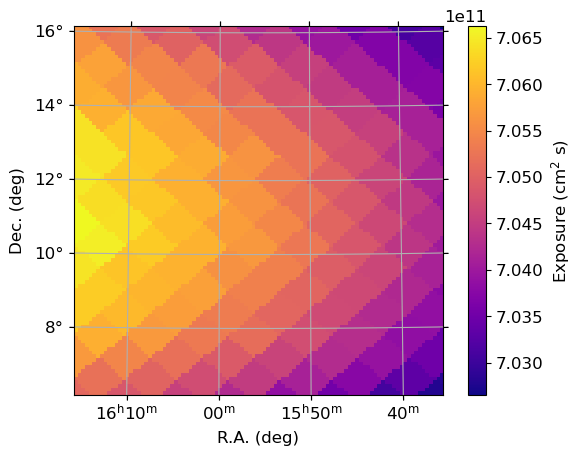

In [12]:
exp = fits.open('bexpmap_roi_00.fits')
exp.info()
exposure = exp[0].data
wcs = WCS(exp[0].header).dropaxis(-1)

plt.subplot(projection=wcs)
im = plt.imshow(np.sum(exposure, axis=0), interpolation='nearest',
                origin='lower', cmap='plasma')
plt.colorbar(im, label=r"Exposure (cm$^{2}$ s)")
plt.grid()
plt.gca().tick_params(direction='out')
plt.gca().set_xlabel("R.A. (deg)")
plt.gca().set_ylabel("Dec. (deg)")

…and the energy dependence of the exposure for the central pixel.

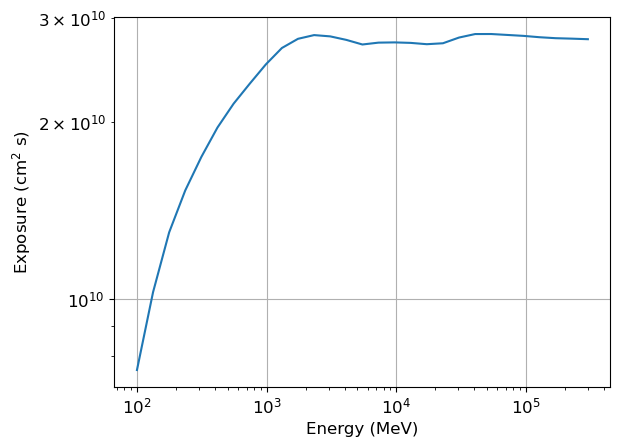

In [13]:
energy = exp[1].data
plt.loglog(energy, exposure[:, 50, 50])
plt.ylabel(r"Exposure (cm$^{2}$ s)")
plt.xlabel("Energy (MeV)")
plt.grid()

We can now inspect the state of the ROI prior to fitting with the `print_roi()` method.

In [14]:
gta.print_roi()

2026-05-04 22:40:38 INFO    GTAnalysis.print_roi(): 
name                SpatialModel   SpectrumType     offset        ts       npred
--------------------------------------------------------------------------------
4FGL J1555.7+1111   PointSource    LogParabola       0.000       nan       847.5
4FGL J1553.6+1257   PointSource    LogParabola       1.838       nan       372.1
4FGL J1603.8+1104   PointSource    PowerLaw          1.994       nan        48.3
4FGL J1552.0+0850   PointSource    PowerLaw          2.516       nan        49.0
4FGL J1608.7+1029   PointSource    LogParabola       3.262       nan       324.7
4FGL J1606.6+1324   PointSource    PowerLaw          3.473       nan        56.4
4FGL J1546.0+0819   PointSource    PowerLaw          3.726       nan        67.8
4FGL J1548.3+1456   PointSource    LogParabola       4.160       nan       158.7
4FGL J1539.1+1008   PointSource    PowerLaw          4.201       nan        48.4
4FGL J1541.7+1413   PointSource    PowerLaw          4.5

Additional details about an individual source can be retrieved by printing the corresponding source object — here PG 1553+113.

In [15]:
print(gta.roi['4FGL J1555.7+1111'])

Name           : 4FGL J1555.7+1111
Associations   : ['4FGL J1555.7+1111', 'PG 1553+113']
RA/DEC         :    238.931/    11.188
GLON/GLAT      :     21.908/    43.962
TS             : nan
Npred          : 847.55
Flux           : 4.546e-08 +/-      nan
EnergyFlux     : 0.0001302 +/-      nan
SpatialModel   : PointSource
SpectrumType   : LogParabola
Spectral Parameters
b'norm'        :  3.602e-12 +/-        nan
b'alpha'       :      1.536 +/-        nan
b'beta'        :    0.07047 +/-        nan
b'Eb'          :       1847 +/-        nan


## Do the likelihood fitting

Now that all of the ancillary files have been generated, we can move on to the actual fitting. The first thing we should do is free some of the sources, since they are all initially fixed. We free those near the centre of the ROI.

In [16]:
gta.free_sources(free=False)                  # make sure everything is fixed first

# Free Normalization of all Sources within 3 deg of ROI center
gta.free_sources(distance=3.0, pars='norm')

# Free normalizations of isotropic and galactic diffuse components
gta.free_source('galdiff', pars='norm')
gta.free_source('isodiff')

2026-05-04 22:40:40 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1555.7+1111     : ['norm']
2026-05-04 22:40:40 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1553.6+1257     : ['norm']
2026-05-04 22:40:40 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1603.8+1104     : ['Prefactor']
2026-05-04 22:40:40 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1552.0+0850     : ['Prefactor']
2026-05-04 22:40:40 INFO    GTAnalysis.free_source(): Freeing parameters for isodiff               : ['Normalization']
2026-05-04 22:40:40 INFO    GTAnalysis.free_source(): Freeing parameters for galdiff               : ['Prefactor']


In this simple analysis we leave the spectral *shapes* of nearby sources fixed but free the full spectral shape of our target.

In [17]:
gta.free_source('4FGL J1555.7+1111')

2026-05-04 22:40:43 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1555.7+1111     : ['alpha', 'beta']


Now actually run the fit. fermipy retries internally to coax the fitter into convergence.

In [18]:
fit_results = gta.fit()

2026-05-04 22:40:45 INFO    GTAnalysis.fit(): Starting fit.
/Users/mcrnogor/miniconda3/envs/fermipy/lib/python3.9/site-packages/fermipy/utils.py:785: UserWarning: 
The maximal number of iterations maxit (set to 20 by the program)
allowed for finding a smoothing spline with fp=s has been reached: s
too small.
There is an approximation returned but the corresponding weighted sum
of squared residuals does not satisfy the condition abs(fp-s)/s < tol.
  spline = UnivariateSpline(x, y, k=2,
2026-05-04 22:40:46 INFO    GTAnalysis.fit(): Fit returned successfully. Quality:   3 Status:   0
2026-05-04 22:40:46 INFO    GTAnalysis.fit(): LogLike:   -48195.574 DeltaLogLike:      278.671 


The dictionary returned by `fit()` carries diagnostics: the fit quality, the relative likelihood improvement, parameter correlations. Let's see what we have in the post-fit source object for PG 1553.

In [19]:
print('Fit Quality:', fit_results['fit_quality'])
print(gta.roi['4FGL J1555.7+1111'])

Fit Quality: 3
Name           : 4FGL J1555.7+1111
Associations   : ['4FGL J1555.7+1111', 'PG 1553+113']
RA/DEC         :    238.931/    11.188
GLON/GLAT      :     21.908/    43.962
TS             : 2807.63
Npred          : 1024.73
Flux           : 5.519e-08 +/- 5.45e-09
EnergyFlux     : 0.0001908 +/- 2.03e-05
SpatialModel   : PointSource
SpectrumType   : LogParabola
Spectral Parameters
b'norm'        :  4.204e-12 +/-  2.219e-13
b'alpha'       :      1.514 +/-    0.04617
b'beta'        :    0.05126 +/-    0.01784
b'Eb'          :       1847 +/-        nan


And take another look at the ROI table and the full parameter list after the fit:

In [20]:
gta.print_roi()

2026-05-04 22:40:49 INFO    GTAnalysis.print_roi(): 
name                SpatialModel   SpectrumType     offset        ts       npred
--------------------------------------------------------------------------------
4FGL J1555.7+1111   PointSource    LogParabola       0.000   2807.63      1024.7
4FGL J1553.6+1257   PointSource    LogParabola       1.838   1130.72      1597.1
4FGL J1603.8+1104   PointSource    PowerLaw          1.994      6.11        48.3
4FGL J1552.0+0850   PointSource    PowerLaw          2.516     54.76       170.2
4FGL J1608.7+1029   PointSource    LogParabola       3.262       nan       324.7
4FGL J1606.6+1324   PointSource    PowerLaw          3.473       nan        56.4
4FGL J1546.0+0819   PointSource    PowerLaw          3.726       nan        67.8
4FGL J1548.3+1456   PointSource    LogParabola       4.160       nan       158.7
4FGL J1539.1+1008   PointSource    PowerLaw          4.201       nan        48.4
4FGL J1541.7+1413   PointSource    PowerLaw          4.5

In [21]:
gta.print_params()

2026-05-04 22:40:50 INFO    GTAnalysis.print_params(): 
 idx parname                  value     error       min       max     scale free
--------------------------------------------------------------------------------
4FGL J1552.0+0850
  42 Prefactor                 3.24     0.636     1e-05     1e+03     1e-13    *
  43 Index                     2.05         0         0         5        -1     
  44 Scale                 1.92e+03         0  1.92e+03  1.92e+03         1     
4FGL J1553.6+1257
  45 norm                      2.57     0.119     1e-05     1e+03     1e-11    *
  46 alpha                     2.28         0        -5         5         1     
  47 beta                     0.115         0        -2         2         1     
  48 Eb                         677         0       677       677         1     
4FGL J1555.7+1111
  49 norm                      0.42    0.0222     1e-05     1e+03     1e-11    *
  50 alpha                     1.51    0.0462        -5         5         1    *

You can save the state of the ROI for later inspection. The first argument prefixes the output files; `make_plots=True` writes a stack of PNG diagnostics.

In [22]:
gta.write_roi('fit0', make_plots=True)

2026-05-04 22:40:51 INFO    GTBinnedAnalysis.write_xml(): Writing /Users/mcrnogor/Library/CloudStorage/Dropbox/lectures/fermipy/lecture/data/pg1553/fit0_00.xml...
2026-05-04 22:40:51 INFO    GTAnalysis.write_fits(): Writing /Users/mcrnogor/Library/CloudStorage/Dropbox/lectures/fermipy/lecture/data/pg1553/fit0.fits...
2026-05-04 22:40:56 INFO    GTAnalysis.write_roi(): Writing /Users/mcrnogor/Library/CloudStorage/Dropbox/lectures/fermipy/lecture/data/pg1553/fit0.npy...


We can also produce the *model map* (predicted counts per pixel under the best-fit model) and load it as a `gammapy.Map` (gammapy is a Cherenkov-telescope analysis package whose multi-dimensional Map class is convenient for this kind of cube; docs: <https://docs.gammapy.org>). We will talk about this in a moment.

In [23]:
model_map = gta.write_model_map("fit0")

2026-05-04 22:41:03 INFO    GTBinnedAnalysis.write_model_map(): Generating model map for component 00.


In [24]:
print(model_map)

[<gammapy.maps.wcs.ndmap.WcsNDMap object at 0x311968e20>, <gammapy.maps.wcs.ndmap.WcsNDMap object at 0x31173afd0>]


Plot the model map summed over the energy axis — predicted counts for *all* model components combined:

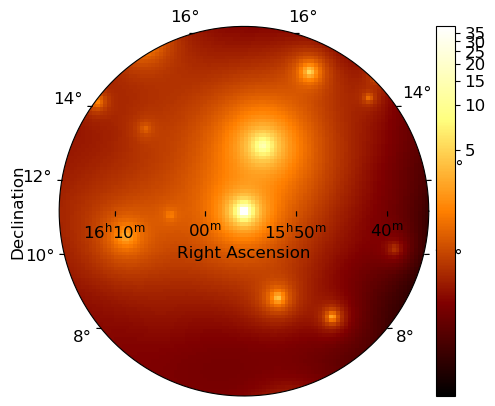

In [26]:
axes = model_map[0].sum_over_axes(["energy"]).plot(stretch='log', add_cbar=True)
plt.show()

Plot each energy bin of the model map. This nicely illustrates the broad PSF at low energies (the source blob is degrees-wide at 100 MeV and shrinks to ≲ 0.1° at 100 GeV).

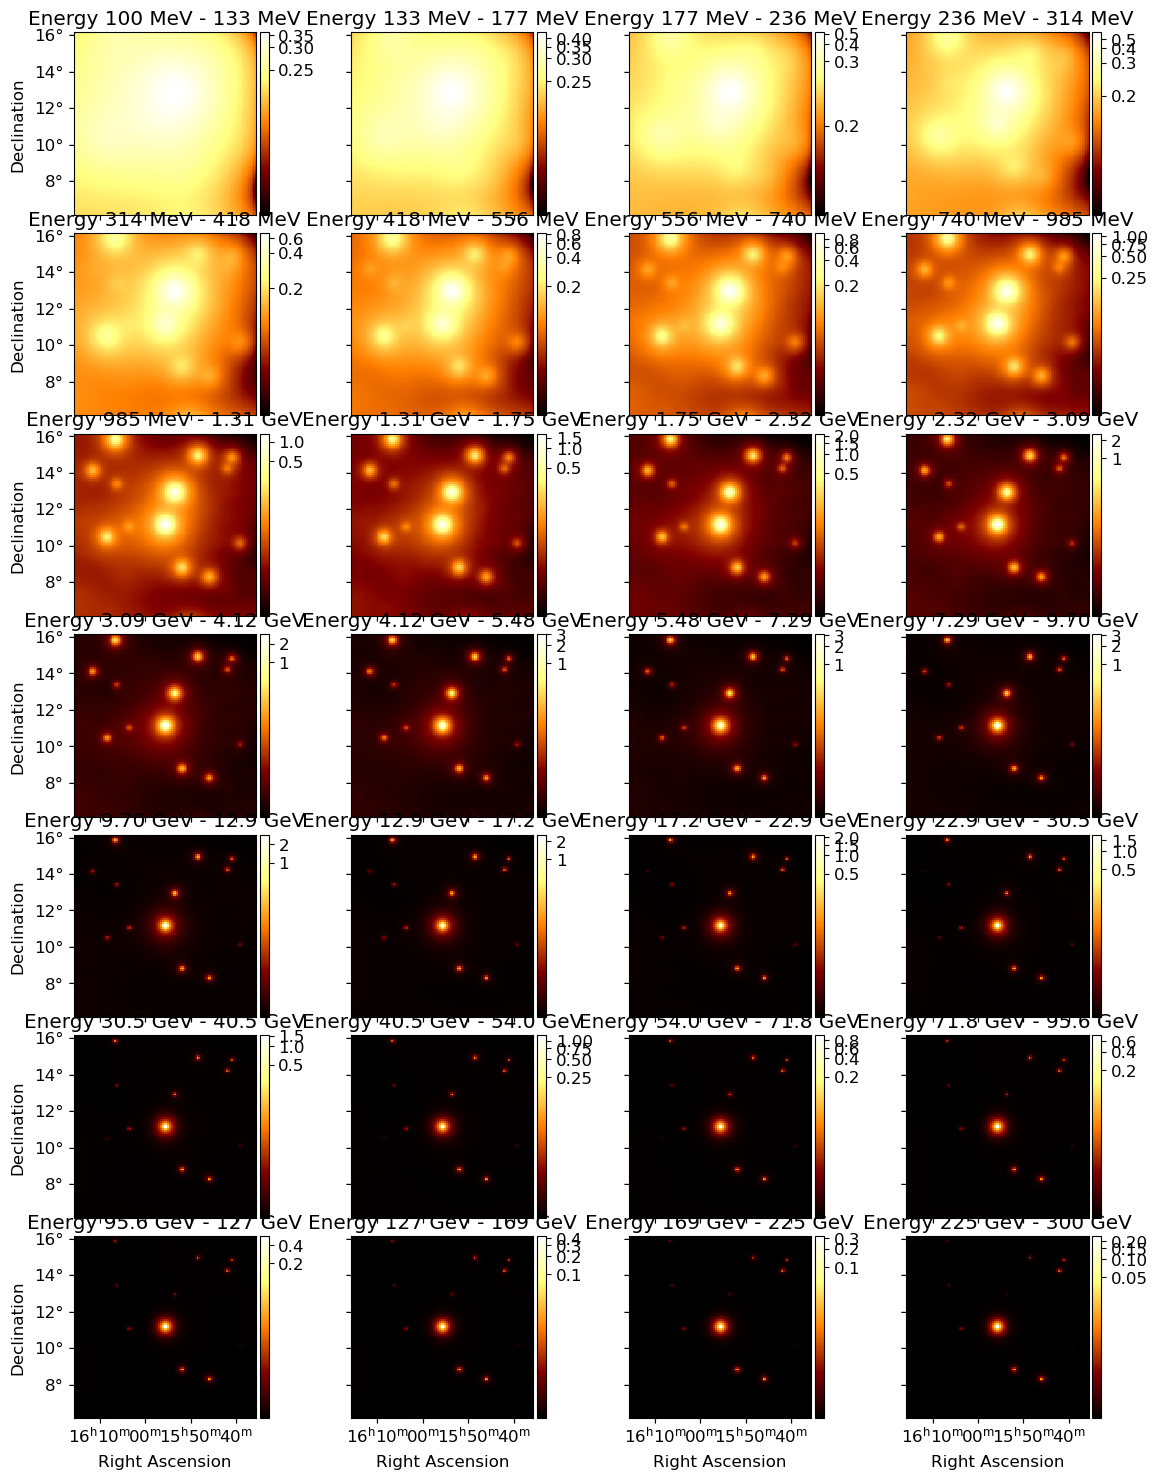

In [27]:
axes = model_map[0].plot_grid(stretch='log', add_cbar=True,
                              figsize=(14, 18), ncols=4)
plt.show()

There are also several diagnostic plots `write_roi` saved to disk — counts map, x/y projections, counts spectrum, model map.

fit0_counts_map_2.000_5.477.png


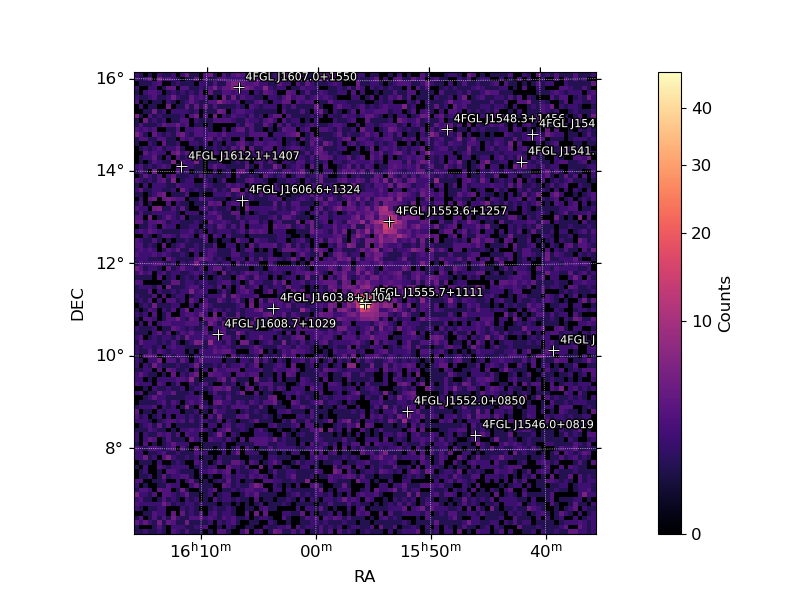

fit0_counts_map_xproj_2.000_5.477.png


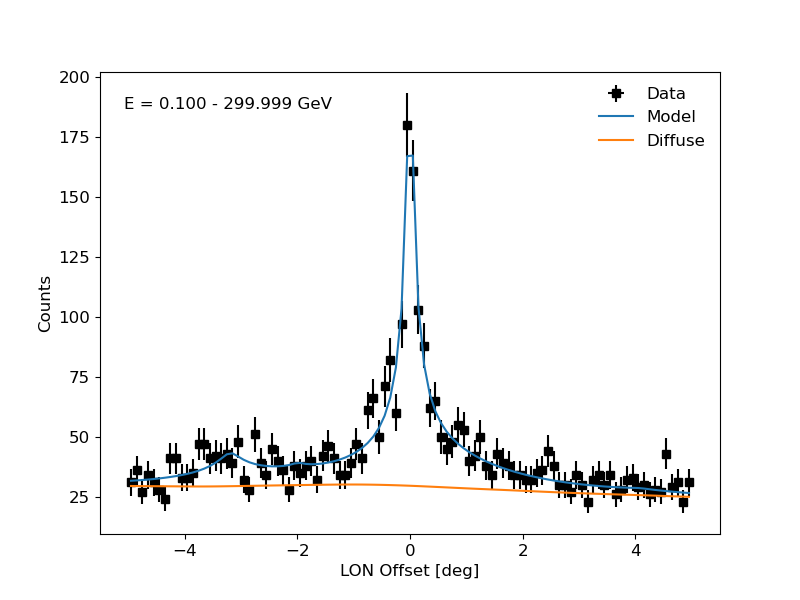

fit0_counts_map_yproj_2.000_5.477.png


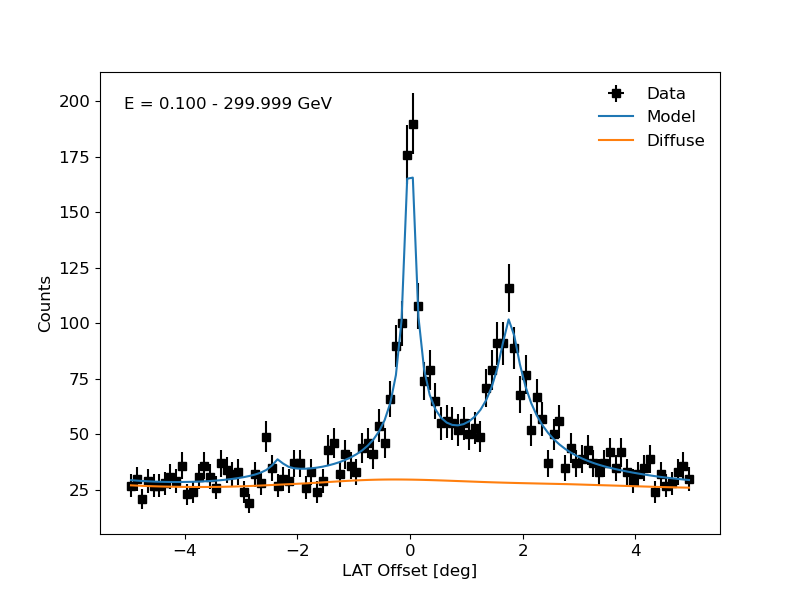

fit0_counts_spectrum.png


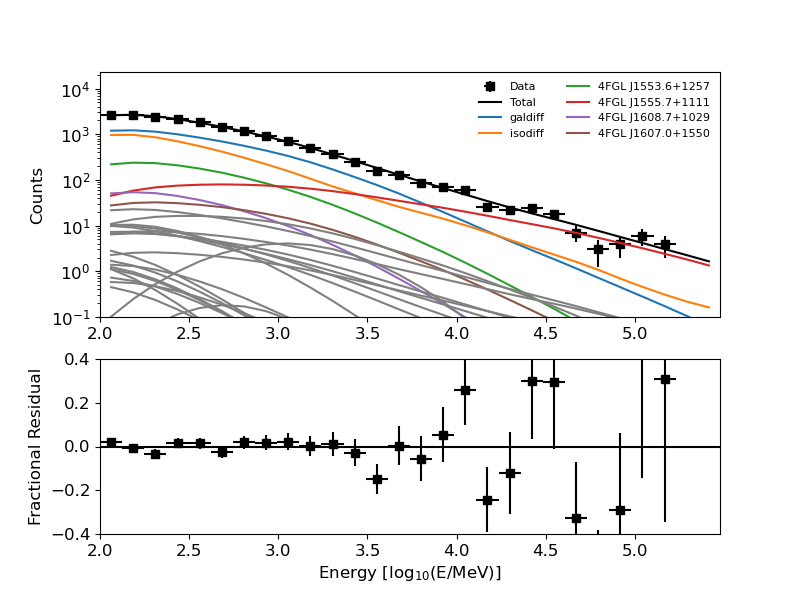

fit0_model_map_2.000_5.477.png


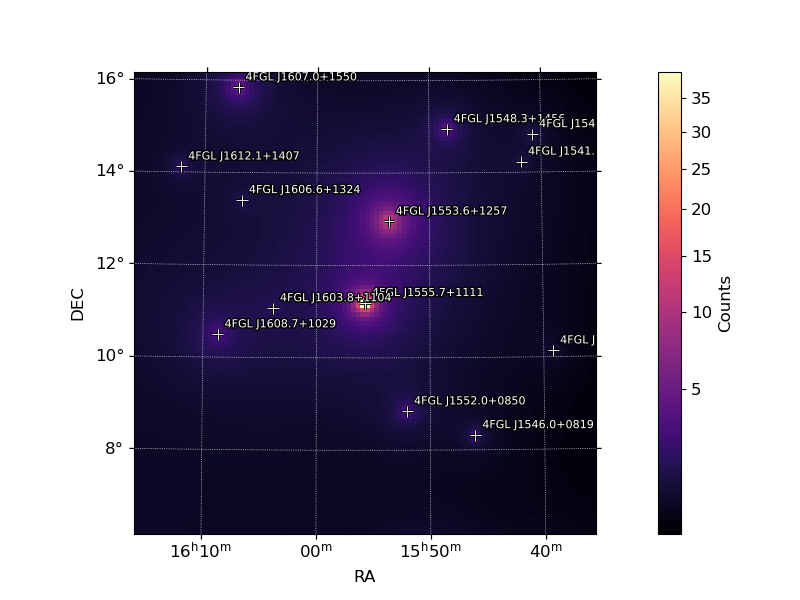

In [28]:
from IPython.display import Image, display
pngs = sorted(glob.glob("fit0_*.png"))
for p in pngs:
    print(p)
    display(Image(p))

### Reading in the results

Since the results are pickled, we can reload them at any time...

In [29]:
c = np.load('fit0.npy', allow_pickle=True).flat[0]

The `sources` dictionary has an entry for each source in the model:

In [30]:
sorted(c['sources'].keys())

['4FGL J1527.8+1013',
 '4FGL J1531.6+0406',
 '4FGL J1538.9+0425',
 '4FGL J1539.1+1008',
 '4FGL J1540.7+1449',
 '4FGL J1541.7+1413',
 '4FGL J1542.3+1801',
 '4FGL J1543.6+0452',
 '4FGL J1546.0+0819',
 '4FGL J1546.5+1816',
 '4FGL J1548.3+1456',
 '4FGL J1549.6+1710',
 '4FGL J1550.7+0528',
 '4FGL J1552.0+0850',
 '4FGL J1553.6+1257',
 '4FGL J1555.7+1111',
 '4FGL J1603.8+1104',
 '4FGL J1606.6+1324',
 '4FGL J1607.0+1550',
 '4FGL J1608.7+1029',
 '4FGL J1612.1+1407',
 '4FGL J1612.4+0409',
 '4FGL J1623.4+0858',
 '4FGL J1626.4+1820',
 'galdiff',
 'isodiff']

And we can pull the flux, spectral parameters, and TS:

In [31]:
print("flux        :", c['sources']['4FGL J1555.7+1111']['flux'])
print("param_names :", c['sources']['4FGL J1555.7+1111']['param_names'][:4])
print("param_values:", c['sources']['4FGL J1555.7+1111']['param_values'][:4])
print("TS          :", c['sources']['4FGL J1555.7+1111']['ts'])

flux        : 5.5194756772401834e-08
param_names : [b'norm' b'alpha' b'beta' b'Eb']
param_values: [4.20394004e-12 1.51417160e+00 5.12589854e-02 1.84673450e+03]
TS          : 2807.6252599068102


The best-fit model SED is also stored in the `model_flux` sub-dictionary. Plot it.

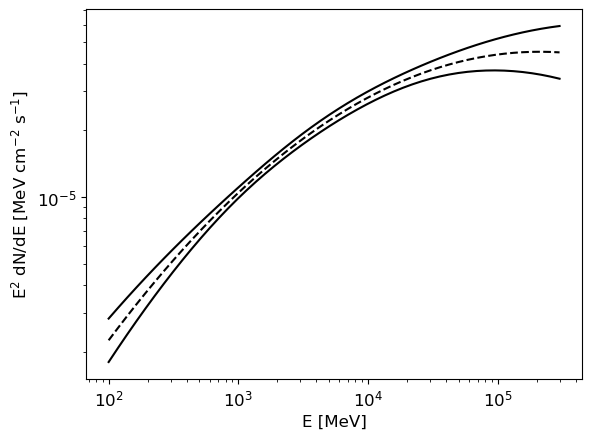

In [32]:
E       = np.array(c['sources']['4FGL J1555.7+1111']['model_flux']['energies'])
dnde    = np.array(c['sources']['4FGL J1555.7+1111']['model_flux']['dnde'])
dnde_hi = np.array(c['sources']['4FGL J1555.7+1111']['model_flux']['dnde_hi'])
dnde_lo = np.array(c['sources']['4FGL J1555.7+1111']['model_flux']['dnde_lo'])

plt.loglog(E, (E**2)*dnde,    'k--')
plt.loglog(E, (E**2)*dnde_hi, 'k')
plt.loglog(E, (E**2)*dnde_lo, 'k')
plt.xlabel('E [MeV]')
plt.ylabel(r'E$^2$ dN/dE [MeV cm$^{-2}$ s$^{-1}$]')
plt.show()

If you want SED *points* (binned likelihood per energy bin, with everything but the bin's normalisation frozen), there's `gta.sed`. Many options can be set in the config file or as keyword arguments — see [`fermipy.gtanalysis.GTAnalysis.sed`](https://fermipy.readthedocs.io/en/latest/fermipy.html#fermipy.gtanalysis.GTAnalysis.sed).

In [33]:
gta.load_roi('fit0')                      
sed = gta.sed('4FGL J1555.7+1111')

2026-05-04 22:41:38 INFO    GTAnalysis.load_roi(): Loading ROI file: /Users/mcrnogor/Library/CloudStorage/Dropbox/lectures/fermipy/lecture/data/pg1553/fit0.npy
2026-05-04 22:41:38 INFO    GTBinnedAnalysis._create_binned_analysis(): Creating BinnedAnalysis for component 00.
2026-05-04 22:41:42 INFO    GTAnalysis.load_roi(): Finished Loading ROI
2026-05-04 22:41:42 INFO    GTAnalysis.sed(): Computing SED for 4FGL J1555.7+1111
2026-05-04 22:41:42 INFO    GTAnalysis._make_sed(): Fitting SED
2026-05-04 22:41:42 INFO    GTAnalysis.free_source(): Fixing parameters for 4FGL J1555.7+1111     : ['alpha', 'beta']
2026-05-04 22:41:50 INFO    GTAnalysis.sed(): Finished SED
2026-05-04 22:41:52 INFO    GTAnalysis.sed(): Execution time: 10.13 s


You can save the state to a yaml file or just access it directly. This is also the way to get at the dictionary for any individual source.

In [34]:
src = gta.roi['4FGL J1555.7+1111']

Plot the SED points on top of the best-fit model band.

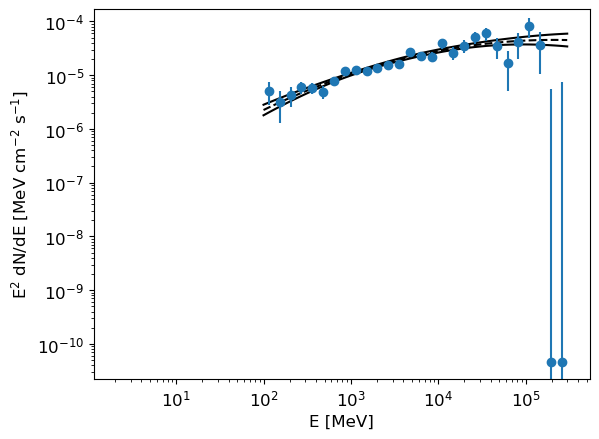

In [35]:
plt.loglog(E, (E**2)*dnde,    'k--')
plt.loglog(E, (E**2)*dnde_hi, 'k')
plt.loglog(E, (E**2)*dnde_lo, 'k')
plt.errorbar(np.array(sed['e_ctr']),
             sed['e2dnde'],
             yerr=sed['e2dnde_err'], fmt='o')
plt.xlabel('E [MeV]')
plt.ylabel(r'E$^{2}$ dN/dE [MeV cm$^{-2}$ s$^{-1}$]')
plt.show()

Looks like the last two points should be upper limits — they're noisy because PG 1553+113 is faint above ~30 GeV in 6.5 months. Replace them with proper 95 % upper limits (`e2dnde_ul95`, drawn as down-arrows).

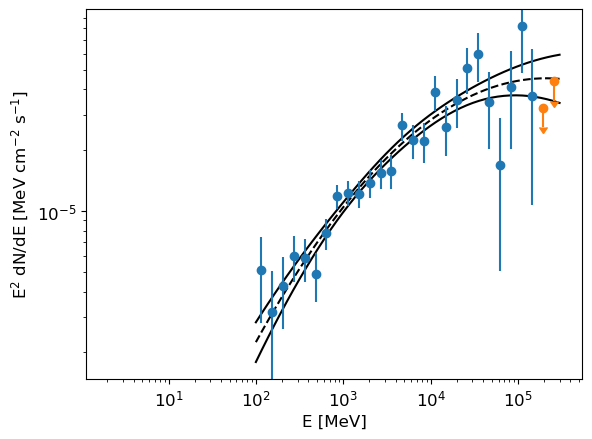

In [36]:
plt.loglog(E, (E**2)*dnde,    'k--')
plt.loglog(E, (E**2)*dnde_hi, 'k')
plt.loglog(E, (E**2)*dnde_lo, 'k')
plt.errorbar(sed['e_ctr'][:-2],
             sed['e2dnde'][:-2],
             yerr=sed['e2dnde_err'][:-2], fmt='o')
plt.errorbar(np.array(sed['e_ctr'][-2:]),
             sed['e2dnde_ul95'][-2:],
             yerr=0.2*sed['e2dnde_ul95'][-2:],
             fmt='o', uplims=True)
plt.xlabel('E [MeV]')
plt.ylabel(r'E$^{2}$ dN/dE [MeV cm$^{-2}$ s$^{-1}$]')
plt.show()

### Summary

There is much more functionality (TS maps, extension tests, event-type splitting, light-curves, …); see the fermipy docs and the rest of `fermipy-extras/notebooks/`. For PG 1553 specifically, we can go further by, for example:

- Re-running with `tmax: 'INDEF'` to use the full mission and reproduce the ~2.2-yr quasi-periodic flux modulation (Ackermann+ 2015, ApJL 813 L41) via `gta.lightcurve(...)` with monthly binning.
- Adding an EBL absorption model on top of the intrinsic spectrum.

Next: the same machinery on a *less* clean and time-variable source — **TXS 0506+056**.